In [ ]:
# ── 라이브러리 불러오기 ──────────────────────────────────────────

# [역할] K-최근접 이웃 분류 모델을 가져옴
# [원리] 새 샘플이 들어오면 훈련 데이터 중 가장 가까운 K개 이웃의 다수결로 클래스 결정
from sklearn.neighbors import KNeighborsClassifier

# [역할] 특성 값들의 크기를 통일시키는 스케일러를 가져옴
# [원리] 각 특성을 (값 - 평균) / 표준편차 로 변환 → 평균=0, 표준편차=1로 맞춤
from sklearn.preprocessing import StandardScaler

# [역할] 표 형태 데이터 처리(pandas), 수치 연산(numpy) 라이브러리를 가져옴
# [원리] pd, np 는 관례적 별칭 — 코드 전체에서 pd.xxx, np.xxx 로 사용
import pandas as pd, numpy as np


# ── 데이터 불러오기 ──────────────────────────────────────────────

# [역할] 같은 폴더의 Fish.csv 파일을 읽어서 DataFrame(표) 형태로 저장
# [원리] CSV = 쉼표로 구분된 텍스트 파일 → pandas가 행/열 표로 변환
# [기본형] pd.read_csv('파일이름.csv')
fish = pd.read_csv('Fish.csv')


# ── 입력 / 타깃 분리 ─────────────────────────────────────────────

# [역할] 모델에 입력할 5개 특성 열만 뽑아서 numpy 배열로 변환
# [원리] fish[['열1','열2',...]] → DataFrame에서 여러 열 선택
#        .to_numpy() → DataFrame을 모델이 읽을 수 있는 numpy 배열로 변환
# [기본형] df[['열이름1','열이름2',...]].to_numpy()
fish_input  = fish[['Weight','Length','Diagonal','Height','Width']].to_numpy()

# [역할] 정답 레이블(물고기 종 이름) 열을 numpy 배열로 변환
# [원리] fish['Species'] → 단일 열 선택 (Series)
#        .to_numpy() → 1차원 배열로 변환 ex) ['Bream','Smelt',...]
# [기본형] df['열이름'].to_numpy()
fish_target = fish['Species'].to_numpy()


# ── 훈련 / 테스트 분할 ───────────────────────────────────────────

# [역할] 훈련 세트와 테스트 세트를 분리하는 함수를 가져옴
from sklearn.model_selection import train_test_split

# [역할] 전체 데이터를 훈련용(75%)과 테스트용(25%)으로 무작위 분할
# [원리] random_state=42 → 분할 시 사용하는 난수 고정
#        → 코드를 몇 번 실행해도 항상 같은 방식으로 분할됨
# [기본형] train_test_split(입력, 타깃, random_state=숫자, stratify도 가능)
# [반환값] 순서대로 훈련입력, 테스트입력, 훈련타깃, 테스트타깃
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)


# ── 스케일링 ─────────────────────────────────────────────────────

# [역할] StandardScaler 객체 생성 (아직 아무것도 안 함, 준비만)
# [원리] 스케일러는 먼저 데이터의 평균과 표준편차를 기억한 뒤 변환
# [기본형] StandardScaler()
ss = StandardScaler()

# [역할] 훈련 데이터로 평균·표준편차를 계산(fit)하고 동시에 변환(transform)
# [원리] fit   → 훈련 데이터의 평균, 표준편차를 ss 내부에 저장
#        transform → 저장된 평균/표준편차로 데이터 변환
#        fit_transform = fit + transform 을 한 번에
# [기본형] ss.fit_transform(훈련데이터)
# ★ 반드시 훈련 데이터에만 fit 해야 함 (테스트 데이터로 fit 하면 데이터 누수)
train_scaled = ss.fit_transform(train_input)

# [역할] 테스트 데이터를 훈련 데이터 기준으로 변환
# [원리] fit 없이 transform만 → 훈련 데이터에서 구한 평균/표준편차를 그대로 사용
#        테스트 데이터로 새로 fit하면 안 됨 → 현실에서 새 데이터가 오면 기준이 없으므로
# [기본형] ss.transform(테스트데이터)
test_scaled  = ss.transform(test_input)


# ── 모델 학습 + 예측 ─────────────────────────────────────────────

# [역할] K=3 으로 설정한 KNN 분류 모델 객체 생성
# [원리] n_neighbors=3 → 새 샘플 주변 가장 가까운 3개 이웃의 다수결로 클래스 결정
# [기본형] KNeighborsClassifier(n_neighbors=K)
kn = KNeighborsClassifier(n_neighbors=3)

# [역할] 스케일링된 훈련 데이터로 모델 학습
# [원리] KNN은 사실 학습이 없음 → 훈련 데이터를 그대로 메모리에 저장해둠
#        예측할 때 저장된 데이터와 거리를 계산
# [기본형] 모델.fit(훈련입력, 훈련타깃)
kn.fit(train_scaled, train_target)

# [역할] 테스트 데이터 앞 5개 샘플에 대해 각 클래스별 확률을 출력
# [원리] predict_proba → 클래스별 확률 반환 (이웃 3개 중 몇 개가 해당 클래스인지)
#        ex) n_neighbors=3 이면 가능한 확률: 0/3=0.0, 1/3=0.33, 2/3=0.67, 3/3=1.0
#        열 순서 = kn.classes_ 알파벳 순서
# [기본형] 모델.predict_proba(입력데이터)
print(kn.predict_proba(test_scaled[:5]))

[[0.         0.         1.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.         1.
  0.        ]
 [0.         0.         0.         1.         0.         0.
  0.        ]
 [0.         0.         0.66666667 0.         0.33333333 0.
  0.        ]
 [0.         0.         0.66666667 0.         0.33333333 0.
  0.        ]]


In [26]:
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


C:\Users\kim\AppData\Local\Temp\ipykernel_7992\4234803635.py:274: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_7992\4234803635.py:274: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_7992\4234803635.py:274: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_7992\4234803635.py:274: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_7992\4234803635.py:274: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_7992\4234803635.py:274: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) D

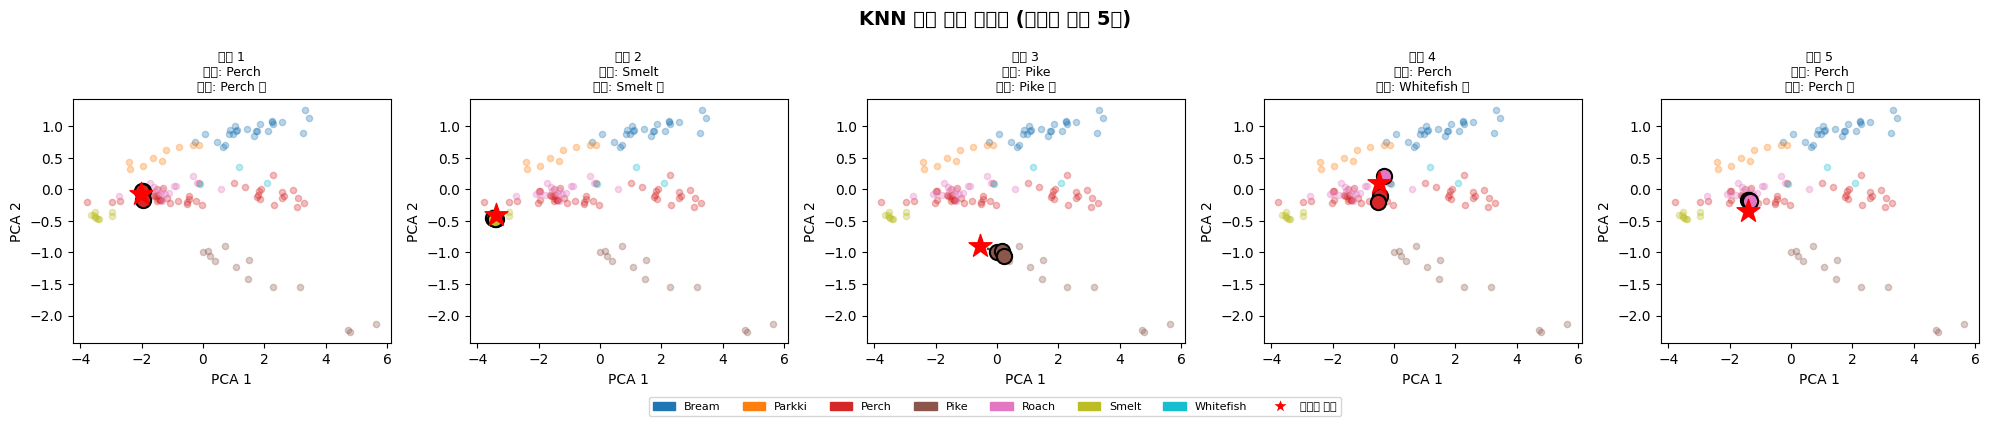

저장 완료: knn_neighbors.png


In [27]:
# ── 라이브러리 불러오기 ──────────────────────────────────────────

# [역할] K-최근접 이웃 분류 모델을 가져옴
# [원리] 새 샘플이 들어오면 훈련 데이터 중 가장 가까운 K개 이웃의 다수결로 클래스 결정
from sklearn.neighbors import KNeighborsClassifier

# [역할] 특성 값들의 크기를 통일시키는 스케일러를 가져옴
# [원리] 각 특성을 (값 - 평균) / 표준편차 로 변환 → 평균=0, 표준편차=1로 맞춤
from sklearn.preprocessing import StandardScaler

# [역할] 5차원 데이터를 2차원으로 압축하는 PCA를 가져옴
# [원리] PCA = 주성분 분석. 정보 손실을 최소화하면서 차원을 줄임
#        5개 특성 → 2개 축으로 압축해서 그래프에 그릴 수 있게 함
from sklearn.decomposition import PCA

# [역할] 표 형태 데이터 처리(pandas), 수치 연산(numpy) 라이브러리를 가져옴
# [원리] pd, np 는 관례적 별칭 — 코드 전체에서 pd.xxx, np.xxx 로 사용
import pandas as pd, numpy as np

# [역할] 그래프를 그리는 라이브러리를 가져옴
# [원리] plt 는 관례적 별칭 — plt.scatter(), plt.show() 등으로 사용
import matplotlib.pyplot as plt

# [역할] 그래프 범례에 색깔 네모 박스(패치)를 만들기 위해 가져옴
# [원리] mpatches.Patch() → 색상+라벨을 가진 범례 항목 생성
import matplotlib.patches as mpatches


# ── 데이터 준비 (기존 코드 동일) ──────────────────────────────────

# [역할] 같은 폴더의 Fish.csv 파일을 읽어서 DataFrame(표) 형태로 저장
fish = pd.read_csv('Fish.csv')

# [역할] 모델에 입력할 5개 특성 열만 뽑아서 numpy 배열로 변환
# [기본형] df[['열이름1','열이름2',...]].to_numpy()
fish_input  = fish[['Weight','Length','Diagonal','Height','Width']].to_numpy()

# [역할] 정답 레이블(물고기 종 이름) 열을 numpy 배열로 변환
# [기본형] df['열이름'].to_numpy()
fish_target = fish['Species'].to_numpy()

# [역할] 훈련 세트와 테스트 세트를 분리하는 함수를 가져옴
from sklearn.model_selection import train_test_split

# [역할] 전체 데이터를 훈련용(75%)과 테스트용(25%)으로 무작위 분할
# [원리] random_state=42 → 난수 고정 → 매번 실행해도 동일한 분할 결과
# [기본형] train_test_split(입력, 타깃, random_state=숫자)
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)

# [역할] StandardScaler 객체 생성
# [기본형] StandardScaler()
ss = StandardScaler()

# [역할] 훈련 데이터로 평균·표준편차를 계산하고 동시에 변환
# [기본형] ss.fit_transform(훈련데이터)
train_scaled = ss.fit_transform(train_input)

# [역할] 테스트 데이터를 훈련 데이터 기준으로 변환만 함
# [기본형] ss.transform(테스트데이터)
test_scaled  = ss.transform(test_input)

# [역할] K=3 으로 설정한 KNN 분류 모델 객체 생성
# [기본형] KNeighborsClassifier(n_neighbors=K)
kn = KNeighborsClassifier(n_neighbors=3)

# [역할] 스케일링된 훈련 데이터로 모델 학습
# [기본형] 모델.fit(훈련입력, 훈련타깃)
kn.fit(train_scaled, train_target)


# ── 5차원 → 2차원 축소 ───────────────────────────────────────────

# [역할] 2차원으로 압축하는 PCA 객체 생성
# [원리] n_components=2 → 최종 출력 차원 수를 2로 지정
#        random_state=42 → 결과 재현을 위한 난수 고정
# [기본형] PCA(n_components=줄일차원수, random_state=숫자)
pca = PCA(n_components=2, random_state=42)

# [역할] 훈련 데이터로 PCA 기준을 학습하고 동시에 2차원으로 변환
# [원리] fit → "5차원에서 어떤 방향이 정보를 가장 많이 담는지" 계산해서 기억
#        transform → 기억한 방향으로 데이터를 2차원 좌표로 변환
# [기본형] pca.fit_transform(훈련데이터)
# ★ 시각화 전용 — 모델 학습은 원본 5차원으로 이미 완료됨
train_2d = pca.fit_transform(train_scaled)

# [역할] 테스트 데이터를 훈련 기준 PCA로 변환 (fit 없이 transform만)
# [원리] 스케일러와 동일한 이유 — 기준은 훈련 데이터에서만 만들어야 함
# [기본형] pca.transform(테스트데이터)
test_2d  = pca.transform(test_scaled)


# ── 시각화할 테스트 샘플 5개 선택 ────────────────────────────────

# [역할] 시각화할 테스트 샘플 수를 5로 고정
# [원리] 변수로 빼두면 나중에 숫자 하나만 바꿔서 샘플 수 조절 가능
n_samples = 5

# [역할] 테스트 샘플 앞 5개를 2차원 좌표로 추출 (그래프용)
# [원리] test_2d[:5] → 0번~4번 행 선택 (슬라이싱)
# [기본형] 배열[:n]
test_samples_2d     = test_2d[:n_samples]

# [역할] 테스트 샘플 앞 5개를 스케일링된 원본 5차원으로 추출 (이웃 탐색용)
# [원리] 이웃 탐색은 원본 5차원 기준으로 해야 정확함 (2차원으로 압축하면 정보 손실)
test_samples_scaled = test_scaled[:n_samples]


# ── 각 테스트 샘플의 이웃 3개 인덱스 찾기 ────────────────────────

# [역할] 각 테스트 샘플에서 가장 가까운 이웃 3개의 거리와 인덱스를 반환
# [원리] kneighbors() → 학습된 훈련 데이터 중 가장 가까운 K개를 찾아줌
#        distances      → 각 이웃까지의 거리 (숫자)
#        neighbor_indices → 훈련 데이터에서 해당 이웃의 위치(몇 번째 행인지)
# [기본형] 모델.kneighbors(입력데이터)
distances, neighbor_indices = kn.kneighbors(test_samples_scaled)


# ── 종별 색상 지정 ────────────────────────────────────────────────

# [역할] 훈련 데이터에 등장하는 종 이름을 중복 없이 알파벳 순으로 정렬해서 추출
# [원리] np.unique() → 배열에서 중복 제거 후 정렬된 고유값 반환
# [기본형] np.unique(배열)
species_list = np.unique(train_target)

# [역할] 종 개수만큼 색상을 균등 간격으로 추출
# [원리] plt.cm.tab10 → matplotlib 내장 10색 팔레트
#        np.linspace(0, 1, n) → 0~1 사이를 n등분한 숫자 배열 생성
#        → 팔레트에서 n개 색상을 균등하게 뽑음
# [기본형] plt.cm.팔레트이름(np.linspace(0, 1, 색상수))
colors = plt.cm.tab10(np.linspace(0, 1, len(species_list)))

# [역할] 종 이름 → 색상 을 바로 찾을 수 있는 딕셔너리 생성
# [원리] enumerate(species_list) → (0,'Bream'), (1,'Parkki'), ... 순서+값 쌍 반환
#        { sp: colors[i] for ... } → 딕셔너리 컴프리헨션으로 한 번에 생성
# [기본형] {키: 값 for i, 키 in enumerate(리스트)}
# [결과 예시] {'Bream': (R,G,B,A), 'Parkki': (R,G,B,A), ...}
color_map = {sp: colors[i] for i, sp in enumerate(species_list)}


# ── 그래프 그리기 ─────────────────────────────────────────────────

# [역할] 1행 5열 구조의 서브플롯(작은 그래프 5개) 생성
# [원리] fig → 전체 캔버스 (액자), axes → 각 칸의 그래프 배열
#        figsize=(20, 4) → 전체 가로 20인치, 세로 4인치
# [기본형] plt.subplots(행수, 열수, figsize=(가로, 세로))
fig, axes = plt.subplots(1, n_samples, figsize=(20, 4))

# [역할] 전체 그래프 상단에 공통 제목 추가
# [원리] fig.suptitle() → 모든 서브플롯 위에 걸리는 큰 제목
# [기본형] fig.suptitle('제목', fontsize=크기, fontweight='bold')
fig.suptitle('KNN 이웃 관계 시각화 (테스트 샘플 5개)', fontsize=14, fontweight='bold')


# ── 테스트 샘플 5개를 순서대로 반복 ──────────────────────────────

for i in range(n_samples):

    # [역할] i번째 서브플롯(그래프 칸)을 꺼내서 ax 변수에 저장
    # [원리] axes[i] → 5개 그래프 중 i번째 그래프 객체
    ax = axes[i]

    # [역할] 훈련 데이터 전체를 종별 색상으로 산점도에 표시
    for sp in species_list:

        # [역할] 현재 종(sp)에 해당하는 훈련 샘플만 True/False 배열로 선택
        # [원리] train_target == sp → 각 원소가 sp와 같으면 True, 다르면 False
        #        mask를 인덱스로 쓰면 True인 행만 선택됨
        # [기본형] 배열 == 값  →  Boolean 배열
        mask = (train_target == sp)

        # [역할] 해당 종의 훈련 샘플을 연한 점으로 표시
        # [원리] train_2d[mask, 0] → 2차원 좌표에서 x축 값 (PCA 1번째 축)
        #        train_2d[mask, 1] → y축 값 (PCA 2번째 축)
        #        alpha=0.3 → 투명도 30% (배경처럼 흐리게)
        #        s=20 → 점 크기 20
        # [기본형] ax.scatter(x값배열, y값배열, color=색상, alpha=투명도, s=점크기)
        ax.scatter(train_2d[mask, 0], train_2d[mask, 1],
                   color=color_map[sp], alpha=0.3, s=20, label=sp)

    # [역할] i번째 테스트 샘플의 이웃 3개 인덱스를 꺼냄
    # [원리] neighbor_indices[i] → i번째 샘플의 이웃 인덱스 배열 (길이 3)
    nbr_idx = neighbor_indices[i]

    # [역할] 이웃 3개를 진한 점으로 강조 표시하고 테스트 샘플과 점선으로 연결
    for j, idx in enumerate(nbr_idx):

        # [역할] 현재 이웃(idx번째 훈련 샘플)의 종 이름 확인
        sp = train_target[idx]

        # [역할] 이웃 점을 진하고 크게, 검은 테두리와 함께 표시
        # [원리] edgecolors='black' → 점 테두리를 검은색으로
        #        linewidths=1.5 → 테두리 두께
        #        zorder=5 → 다른 점들보다 앞에 그림 (숫자 클수록 앞)
        # [기본형] ax.scatter(x, y, s=크기, edgecolors=색, linewidths=두께, zorder=순서)
        ax.scatter(train_2d[idx, 0], train_2d[idx, 1],
                   color=color_map[sp], s=120, edgecolors='black', linewidths=1.5,
                   zorder=5)

        # [역할] 테스트 샘플 위치 → 이웃 위치 를 점선으로 연결
        # [원리] ax.plot([x1, x2], [y1, y2]) → 두 점을 잇는 선 그리기
        #        'k--' → k=검은색, --=점선
        #        alpha=0.5 → 선 투명도 50%
        # [기본형] ax.plot([x시작, x끝], [y시작, y끝], '색상+선스타일', alpha=투명도)
        ax.plot([test_samples_2d[i, 0], train_2d[idx, 0]],
                [test_samples_2d[i, 1], train_2d[idx, 1]],
                'k--', alpha=0.5, linewidth=1)

    # [역할] 테스트 샘플을 빨간 별(★)로 표시
    # [원리] marker='*' → 별 모양 마커
    #        s=300 → 크게 표시해서 눈에 띄게
    #        zorder=6 → 이웃 점(zorder=5)보다 앞에 그림
    # [기본형] ax.scatter(x, y, color=색상, marker='마커모양', s=크기, zorder=순서)
    ax.scatter(test_samples_2d[i, 0], test_samples_2d[i, 1],
               color='red', marker='*', s=300, zorder=6,
               label='테스트 샘플')

    # [역할] 모델의 예측 결과를 1개 샘플에 대해 반환
    # [원리] predict() → 확률이 가장 높은 클래스 이름 반환
    #        i:i+1 → 슬라이싱으로 2차원 배열 유지 (predict는 2차원 배열 필요)
    #        [0] → 결과 배열에서 첫 번째(유일한) 값을 꺼냄
    # [기본형] 모델.predict(입력)[0]
    pred   = kn.predict(test_samples_scaled[i:i+1])[0]

    # [역할] i번째 테스트 샘플의 실제 정답 종 이름
    actual = test_target[i]

    # [역할] 예측과 정답이 같으면 ✅, 다르면 ❌ 기호 선택
    # [원리] 삼항 연산자: 조건이 True면 앞값, False면 뒷값
    # [기본형] 값A if 조건 else 값B
    match = '✅' if pred == actual else '❌'

    # [역할] 서브플롯 제목에 예측/실제/일치여부 표시
    # [원리] \n → 줄바꿈 문자
    # [기본형] ax.set_title('제목', fontsize=크기)
    ax.set_title(f'샘플 {i+1}\n예측: {pred}\n실제: {actual} {match}', fontsize=9)

    # [역할] x축, y축 레이블 표시
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')


# ── 범례 생성 ─────────────────────────────────────────────────────

# [역할] 종별 색상 패치(색깔 네모) 목록 생성
# [원리] mpatches.Patch(color=색상, label=이름) → 범례에 들어갈 색깔 박스 1개
#        리스트 컴프리헨션으로 종 개수만큼 한 번에 생성
# [기본형] [mpatches.Patch(color=색상, label=이름) for sp in 종목록]
legend_patches = [mpatches.Patch(color=color_map[sp], label=sp)
                  for sp in species_list]

# [역할] 범례에 "테스트 샘플 = 빨간 별" 항목 추가
# [원리] plt.Line2D → 선+마커 조합으로 범례 항목 생성
#        color='w' → 선 색상 흰색(안 보이게), markerfacecolor='red' → 별 색상만 빨강
# [기본형] plt.Line2D([0],[0], marker='마커', color='선색', markerfacecolor='마커색')
legend_patches.append(plt.Line2D([0], [0], marker='*', color='w',
                                  markerfacecolor='red', markersize=12,
                                  label='테스트 샘플'))

# [역할] 전체 그래프 하단에 공통 범례 표시
# [원리] loc='lower center' → 그래프 하단 중앙
#        ncol=8 → 범례 항목을 8열로 나란히 배치
#        bbox_to_anchor=(0.5, -0.05) → 범례 위치를 그래프 바깥 아래로 내림
# [기본형] fig.legend(handles=패치목록, loc=위치, ncol=열수, bbox_to_anchor=(x,y))
fig.legend(handles=legend_patches,
           loc='lower center', ncol=8,
           fontsize=8, bbox_to_anchor=(0.5, -0.05))


# ── 출력 및 저장 ──────────────────────────────────────────────────

# [역할] 서브플롯 간격을 자동으로 조정해서 겹치지 않게 함
# [기본형] plt.tight_layout()
plt.tight_layout()

# [역할] 그래프를 PNG 파일로 저장
# [원리] dpi=150 → 해상도 150 (높을수록 선명, 파일 커짐)
#        bbox_inches='tight' → 범례가 잘리지 않도록 여백 자동 조정
# [기본형] plt.savefig('파일이름.png', dpi=해상도, bbox_inches='tight')
plt.savefig('knn_neighbors.png', dpi=150, bbox_inches='tight')

# [역할] 그래프를 화면에 출력
# [기본형] plt.show()
plt.show()

print("저장 완료: knn_neighbors.png")

로지스틱 회귀

In [28]:
from sklearn.linear_model import LogisticRegression

bream_smelt_indexes = (train_target == "Bream") | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

In [29]:
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)
print(lr.classes_)
print(lr.coef_)
print(lr.intercept_)

['Bream' 'Smelt']
[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]]
[-2.16172774]


In [30]:
decision = lr.decision_function(train_bream_smelt[:5])
print(decision)


[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]


In [31]:
# expit는 Sigmoid 함수이다.
from scipy.special import expit 
print(expit(decision))

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


C:\Users\kim\AppData\Local\Temp\ipykernel_7992\3285111746.py:173: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_7992\3285111746.py:173: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_7992\3285111746.py:173: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_7992\3285111746.py:173: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_7992\3285111746.py:173: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kim\AppData\Local\Temp\ipykernel_7992\3285111746.py:173: UserWarning: Glyph 47144 (\N{HANGUL SYLLABLE RYEON}) missing from f

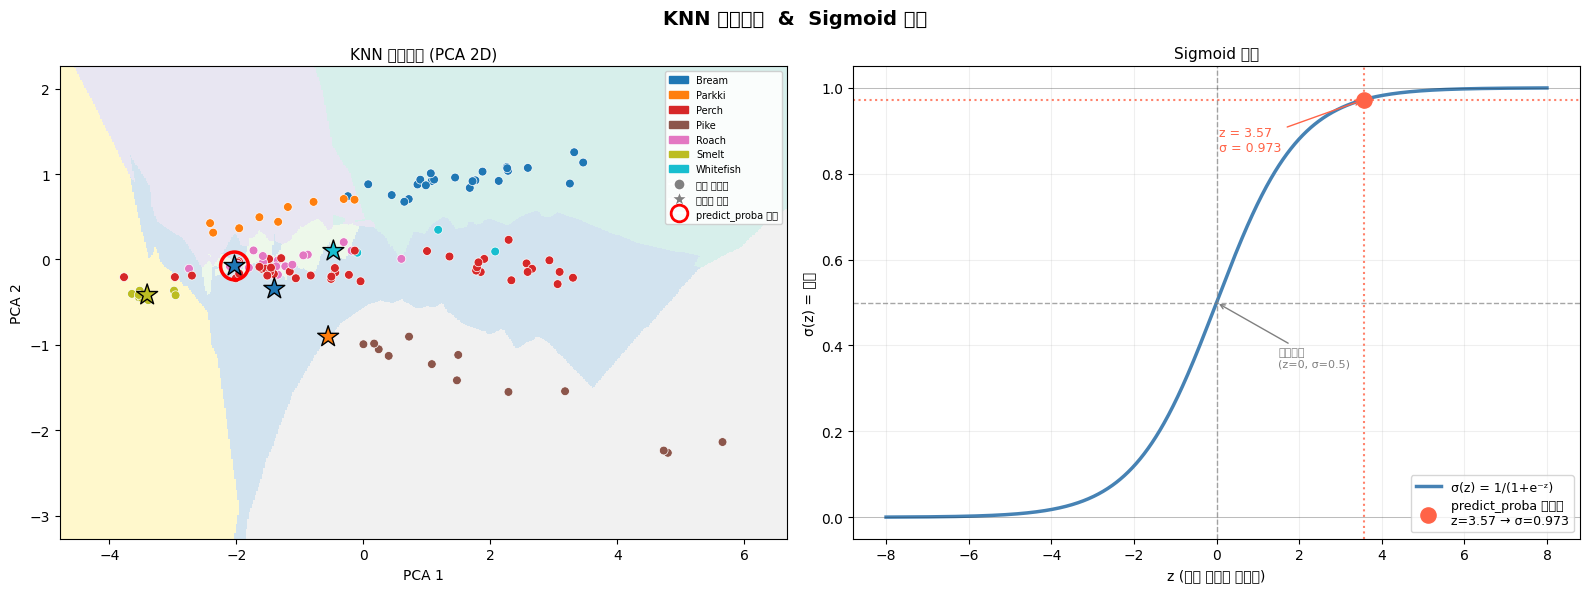

저장 완료: decision_boundary_sigmoid.png


In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ── 데이터 준비 ───────────────────────────────────────────────────
fish        = pd.read_csv('Fish.csv')
fish_input  = fish[['Weight','Length','Diagonal','Height','Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)

ss = StandardScaler()
train_scaled = ss.fit_transform(train_input)
test_scaled  = ss.transform(test_input)

# ── PCA로 2차원 축소 (시각화 전용) ───────────────────────────────
# [역할] 5차원 → 2차원으로 압축 (그래프에 그리기 위해)
# [원리] 정보 손실 최소화하며 2개의 축으로 압축
pca = PCA(n_components=2, random_state=42)
train_2d = pca.fit_transform(train_scaled)
test_2d  = pca.transform(test_scaled)

# ── 2차원 데이터로 KNN 재학습 (결정경계 시각화 전용) ─────────────
# [역할] 결정경계를 2D 평면에 그리려면 2D 모델이 필요
# [원리] 원본 5D 모델과 별개 — 시각화 목적으로만 사용
kn_2d = KNeighborsClassifier(n_neighbors=3)
kn_2d.fit(train_2d, train_target)

# ── 결정경계용 격자(meshgrid) 생성 ───────────────────────────────
# [역할] 2D 평면 전체를 촘촘한 격자점으로 채움
# [원리] 격자점마다 "어느 클래스인가?" 를 예측 → 색깔로 채우면 결정경계가 보임
# [기본형] np.meshgrid(x축범위, y축범위)
x_min, x_max = train_2d[:, 0].min() - 1, train_2d[:, 0].max() + 1
y_min, y_max = train_2d[:, 1].min() - 1, train_2d[:, 1].max() + 1

# [역할] x, y 범위를 각각 500등분한 격자 생성
# [원리] np.linspace(시작, 끝, 개수) → 균등 간격 숫자 배열
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# [역할] 격자점 전체를 (N, 2) 형태로 펼쳐서 한 번에 예측
# [원리] np.c_[a, b] → 두 배열을 열 방향으로 합침
#        xx.ravel() → 2D 격자를 1D 배열로 펼침
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = kn_2d.predict(grid_points)

# [역할] 예측 결과를 숫자로 변환 (색깔 맵에 쓰기 위해)
# [원리] np.unique → 종 이름 목록, searchsorted → 이름을 인덱스 번호로 변환
species_list = np.unique(train_target)
Z_num = np.searchsorted(species_list, Z).reshape(xx.shape)

# ── 색상 팔레트 설정 ──────────────────────────────────────────────
# [역할] 종 개수만큼 색상 생성
colors_soft = plt.cm.Set3(np.linspace(0, 1, len(species_list)))
colors_bold = plt.cm.tab10(np.linspace(0, 1, len(species_list)))
cmap_bg   = ListedColormap(colors_soft)   # 배경 (연한 색)
cmap_dot  = ListedColormap(colors_bold)   # 점   (진한 색)

# ════════════════════════════════════════════════════════════════
# 그래프 1 — 결정경계   /   그래프 2 — Sigmoid 함수
# ════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('KNN 결정경계  &  Sigmoid 함수', fontsize=14, fontweight='bold')


# ════════ 왼쪽: 결정경계 ════════════════════════════════════════

# [역할] 격자점의 예측 클래스를 배경 색으로 채움 → 결정경계가 드러남
# [원리] pcolormesh → 격자를 색깔 타일로 채우는 함수
#        alpha=0.35 → 배경을 반투명하게 (데이터 점이 잘 보이게)
ax1.pcolormesh(xx, yy, Z_num, cmap=cmap_bg, alpha=0.35)

# [역할] 훈련 데이터 점을 종별 색상으로 표시
train_num = np.searchsorted(species_list, train_target)
scatter1 = ax1.scatter(train_2d[:, 0], train_2d[:, 1],
                       c=train_num, cmap=cmap_dot,
                       s=40, edgecolors='white', linewidths=0.5,
                       zorder=3, label='훈련 데이터')

# [역할] 테스트 데이터 앞 5개를 별(★)로 표시
test_num = np.searchsorted(species_list, test_target[:5])
ax1.scatter(test_2d[:5, 0], test_2d[:5, 1],
            c=test_num, cmap=cmap_dot,
            s=250, marker='*', edgecolors='black', linewidths=1,
            zorder=5, label='테스트 샘플 (★)')

# [역할] 첫 번째 테스트 샘플(확률값이 나온 샘플)을 빨간 원으로 강조
# [원리] 문제의 [0.002, 0.973, 0.005, 0.014, 0.002] 결과가 이 샘플
ax1.scatter(test_2d[0, 0], test_2d[0, 1],
            s=400, facecolors='none', edgecolors='red',
            linewidths=2.5, zorder=6, label='predict_proba 출력 샘플')

# [역할] 범례 추가
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=colors_bold[i], label=sp)
           for i, sp in enumerate(species_list)]
patches += [
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor='gray', markersize=8, label='훈련 데이터'),
    plt.Line2D([0],[0], marker='*', color='w',
               markerfacecolor='gray', markersize=12, label='테스트 샘플'),
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor='none', markeredgecolor='red',
               markeredgewidth=2, markersize=12, label='predict_proba 샘플'),
]
ax1.legend(handles=patches, fontsize=7,
           loc='upper right', framealpha=0.9)

ax1.set_title('KNN 결정경계 (PCA 2D)', fontsize=11)
ax1.set_xlabel('PCA 1')
ax1.set_ylabel('PCA 2')


# ════════ 오른쪽: Sigmoid 함수 ═══════════════════════════════════

# [역할] -8 ~ 8 사이를 1000등분한 x 배열 생성
z = np.linspace(-8, 8, 1000)

# [역할] Sigmoid 수식 직접 계산
# [원리] σ(z) = 1 / (1 + e^{-z})
sigmoid = 1 / (1 + np.exp(-z))

# [역할] Sigmoid 곡선 그리기
ax2.plot(z, sigmoid, color='steelblue', linewidth=2.5, label='σ(z) = 1/(1+e⁻ᶻ)')

# [역할] y=0.5 기준선 (결정 경계)
# [원리] z=0 일 때 σ(z)=0.5 → 이 지점이 클래스 결정 경계
ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.axvline(x=0,   color='gray', linestyle='--', linewidth=1, alpha=0.7)

# [역할] predict_proba 결과에서 가장 높은 확률값(0.973)을 Sigmoid 위에 표시
# [원리] σ(z) = 0.973 → z = log(0.973/0.027) ≈ 3.58
prob_val = 0.97262675
z_val    = np.log(prob_val / (1 - prob_val))   # 역함수: log-odds

# [역할] 해당 z값에서 수직선과 수평선으로 좌표 표시
ax2.axvline(x=z_val, color='tomato', linestyle=':', linewidth=1.5, alpha=0.8)
ax2.axhline(y=prob_val, color='tomato', linestyle=':', linewidth=1.5, alpha=0.8)

# [역할] 해당 점을 빨간 점으로 강조
ax2.scatter([z_val], [prob_val], color='tomato', s=120, zorder=5,
            label=f'predict_proba 최고값\nz={z_val:.2f} → σ={prob_val:.3f}')

# [역할] 주요 좌표에 설명 텍스트 추가
ax2.annotate(f'z = {z_val:.2f}\nσ = {prob_val:.3f}',
             xy=(z_val, prob_val),
             xytext=(z_val - 3.5, prob_val - 0.12),
             fontsize=9, color='tomato',
             arrowprops=dict(arrowstyle='->', color='tomato'))

ax2.annotate('결정경계\n(z=0, σ=0.5)', xy=(0, 0.5),
             xytext=(1.5, 0.35), fontsize=8, color='gray',
             arrowprops=dict(arrowstyle='->', color='gray'))

# [역할] y=0, y=1 경계선 표시
ax2.axhline(y=0, color='black', linewidth=0.5, alpha=0.3)
ax2.axhline(y=1, color='black', linewidth=0.5, alpha=0.3)

ax2.set_title('Sigmoid 함수', fontsize=11)
ax2.set_xlabel('z (선형 방정식 출력값)')
ax2.set_ylabel('σ(z) = 확률')
ax2.set_ylim(-0.05, 1.05)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)


# ── 저장 및 출력 ──────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('decision_boundary_sigmoid.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: decision_boundary_sigmoid.png")

<!-- 다중분류 -->
Softmax 함수
- e 지수함수를 적용
- 정규화-> 모든 확률의 합은 100% 되게끔, 하지만 가장 큰 점수를 극대화 시키는 함수

In [33]:
# 전체 7종 분류
lr = LogisticRegression(C=20, max_iter=1000)
# C(규제의 역수) 값은 클수록 규제가 약하고 자유도가 높음
# max_iter는 한번에 결정경계를 못 찾기 때문에 반복 학습 과정을 거침(경사하강법). 


lr.fit(train_scaled, train_target)
print(lr.classes_)
proba = lr.predict_proba(test_scaled[:3])
print(proba.round(3))


['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]]


In [34]:
decision = lr.decision_function(test_scaled[:5])
print(decision.shape)

(5, 7)


In [35]:
from scipy.special import softmax
proba_from_softmax = softmax(decision, axis=1)
proba_from_softmax.round(3) 
# 결과가 로지스틱 회귀의 결과와 같다.
# 다항분류의 경우, softmax를 사용한다.

array([[0.   , 0.014, 0.842, 0.   , 0.135, 0.007, 0.003],
       [0.   , 0.003, 0.044, 0.   , 0.007, 0.946, 0.   ],
       [0.   , 0.   , 0.034, 0.934, 0.015, 0.016, 0.   ],
       [0.011, 0.034, 0.305, 0.006, 0.567, 0.   , 0.076],
       [0.   , 0.   , 0.904, 0.002, 0.089, 0.002, 0.001]])

In [36]:
proba_df = pd.DataFrame(
    lr.predict_proba(test_scaled[:3]).round(3),
    columns=lr.classes_
)
proba_df

,Bream,Parkki,Perch,Pike,Roach,Smelt,Whitefish
0,0.0,0.014,0.842,0.000,0.135,0.007,0.003
1,0.0,0.003,0.044,0.000,0.007,0.946,0.000
2,0.0,0.000,0.034,0.934,0.015,0.016,0.000


In [37]:
# 평가
lr.score(test_scaled, test_target)

0.925

In [38]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
y_true = [1, 0, 1, 1, 0, 1, 0, 0]
y_pred = [1, 0, 0, 1, 0, 1, 1, 0]

confusion_matrix(y_true, y_pred)

array([[3, 1],
       [1, 3]])

In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.75      0.75      0.75         4

    accuracy                           0.75         8
   macro avg       0.75      0.75      0.75         8
weighted avg       0.75      0.75      0.75         8



In [40]:
import seaborn as sns
titanic = sns.load_dataset('titanic')

# 기본 전처리
titanic_clean = titanic[['survived','pclass','sex','age','sibsp','parch','fare']].dropna()

# 인코딩
titanic_clean = pd.get_dummies(titanic_clean, columns=['sex'], drop_first=True)

X = titanic_clean.drop('survived', axis=1).values
y = titanic_clean['survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, stratify=y)  # stratify로 불균형 비율 유지

ss = StandardScaler()
X_train_s = ss.fit_transform(X_train)
X_test_s  = ss.transform(X_test)

print("생존:", y.sum(), "사망:", len(y) - y.sum())
print("생존 비율:", y.mean().round(3))



ModuleNotFoundError: No module named 'seaborn'

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train_s, y_train)
y_pred = lr.predict(X_test_s)
lr.score(X_test_s, y_test)

0.7932960893854749

In [ ]:
from sklearn.metrics import classification_report
confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.82       106
           1       0.74      0.75      0.75        73

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



In [ ]:
# ROC AUC 점수

from sklearn.metrics import roc_auc_score
y_score = lr.predict_proba(X_test_s)[:, 1] #생존확률만 확인, 차원축소
print(y_score[:3])
roc_auc_score(y_test, y_score)

[0.08897927 0.20280058 0.09118474]


0.8634660118893771

In [ ]:
# 임
from sklearn.linear_model import LogisticRegression


y_score_30 = (y_score >= 0.3).astype(int)
classification_report(y_test, y_score_30, target_names=['사망', '생존'])

# 임계값을 0.3으로 낮췄을 때 (생존 기준)으로 리콜(재현률)이 오르고 정밀도 낮아짐.



'              precision    recall  f1-score   support\n\n          사망       0.85      0.69      0.76       106\n          생존       0.65      0.82      0.72        73\n\n    accuracy                           0.74       179\n   macro avg       0.75      0.76      0.74       179\nweighted avg       0.77      0.74      0.75       179\n'

In [ ]:
# SGD 확률적 경사 하강법
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', random_state=42)
# SGD에서는 손실함수를 어떤 것으로 할 지 선택해야 한다.
# 손실함수를 log_loss로 선정함으로 내부적으로 로지스틱 회귀를 사용한다.
train_score, test_score = [], []
classes = np.unique(train_target)
for _ in range(300):
    sc.partial_fit(train_scaled, train_target,
                    classes=classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

In [ ]:
train_score

[0.5294117647058824,
 0.6218487394957983,
 0.6386554621848739,
 0.7142857142857143,
 0.7142857142857143,
 0.7394957983193278,
 0.7058823529411765,
 0.7226890756302521,
 0.7563025210084033,
 0.8067226890756303,
 0.8151260504201681,
 0.8487394957983193,
 0.8403361344537815,
 0.8571428571428571,
 0.8739495798319328,
 0.8571428571428571,
 0.8571428571428571,
 0.8739495798319328,
 0.8739495798319328,
 0.8739495798319328,
 0.8907563025210085,
 0.8739495798319328,
 0.8739495798319328,
 0.8823529411764706,
 0.8907563025210085,
 0.8907563025210085,
 0.8739495798319328,
 0.8991596638655462,
 0.8991596638655462,
 0.8991596638655462,
 0.8991596638655462,
 0.8907563025210085,
 0.8907563025210085,
 0.8823529411764706,
 0.907563025210084,
 0.8991596638655462,
 0.9243697478991597,
 0.907563025210084,
 0.9243697478991597,
 0.9159663865546218,
 0.9159663865546218,
 0.9243697478991597,
 0.9327731092436975,
 0.9243697478991597,
 0.9327731092436975,
 0.9243697478991597,
 0.9327731092436975,
 0.932773109243

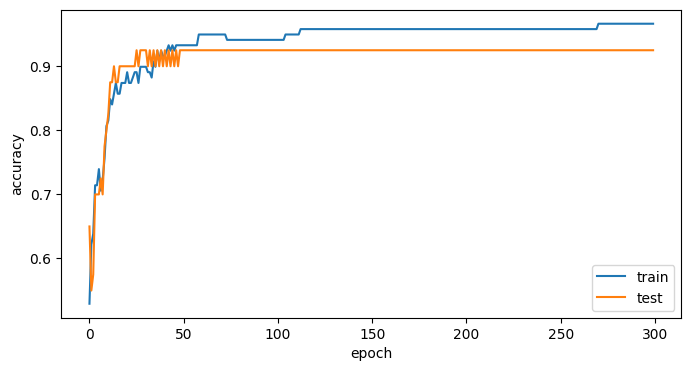

In [ ]:
# 최적의 에폭을 찾아라.!!!!! 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(train_score, label='train')
plt.plot(test_score,  label='test')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

위를 보면 50부근에서 test 데이터의 정확도가 더 이상 증가하지 않는 것을 볼 수 있다. 그리고 동시에 훈련 데이터의 정확도가 상승하는 것을 확인할 수 있는데 이 경우에 과적합 문제가 발생할 수 있기에 우리는 시각화를 통해 50부근에서 테스트 데이터의 정확도가 더 이상 상승하지 않는 것을 보았고, 50에서 에포크를 조기종료해야 한다라는 결론에 도달한다.그러면 조기 종료는 어케함?

방법 1 — 수동으로 멈추기 (가장 단순)
그래프를 보고 눈으로 확인한 뒤 에포크 수를 직접 지정합니다

In [ ]:
# [정의]    SGD(확률적 경사 하강법) 기반 분류 모델
# [기본형]  SGDClassifier(loss='손실함수', max_iter=에포크수, random_state=숫자)
# [역할]    로그 손실 함수를 쓰는 SGD 분류기를 생성하고
#            max_iter=50 으로 에포크 수를 직접 50으로 고정
# [사용이유] 그래프에서 epoch 50이 최적임을 눈으로 확인했으므로
#            그 값을 직접 지정해서 과적합 없이 학습을 마치기 위해
sc = SGDClassifier(loss='log_loss', max_iter=50, random_state=42)

# [정의]    모델에 전체 데이터를 학습시키는 메서드
# [기본형]  모델.fit(훈련입력, 훈련타깃)
# [역할]    스케일링된 훈련 데이터로 50에포크 동안 학습
# [사용이유] max_iter=50 이므로 자동으로 50번만 반복하고 멈춤
sc.fit(train_scaled, train_target)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",50
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


방법 2 — 코드로 자동 멈추기 (핵심)

In [ ]:
# [정의]    SGD 분류 모델 클래스
# [기본형]  SGDClassifier(loss='손실함수', random_state=숫자)
# [역할]    SGD 분류기 객체 생성 (max_iter 지정 안 함 → 직접 반복문으로 제어)
# [사용이유] partial_fit으로 에포크를 하나씩 수동 제어하기 위해
#            max_iter를 지정하면 fit()이 자동으로 멈추므로 여기선 쓰지 않음
from sklearn.linear_model import SGDClassifier
import numpy as np

sc = SGDClassifier(loss='log_loss', random_state=42)

# [정의]    각 에포크의 훈련/테스트 점수를 누적하는 리스트
# [기본형]  변수 = []
# [역할]    에포크마다 점수를 append해서 나중에 그래프를 그리거나 분석하기 위해 저장
# [사용이유] 점수 변화를 추적해야 최적 에포크를 찾을 수 있기 때문
train_score = []
test_score  = []

# [정의]    지금까지 기록된 가장 높은 test 점수를 저장하는 변수
# [기본형]  변수 = 0
# [역할]    새 에포크 점수와 비교해서 갱신 여부를 판단하는 기준값
# [사용이유] test 점수가 이 값을 넘으면 "아직 개선 중", 못 넘으면 "정체 중"으로 판단
best_score = 0

# [정의]    가장 높은 test 점수가 나온 에포크 번호를 저장하는 변수
# [기본형]  변수 = 0
# [역할]    조기 종료 조건(patience)을 계산할 때 기준점으로 사용
# [사용이유] "마지막으로 개선된 에포크에서 몇 번이나 지났는가"를 계산하기 위해
best_epoch = 0

# [정의]    test 점수가 개선되지 않아도 기다리는 최대 에포크 수
# [기본형]  변수 = 숫자
# [역할]    patience=10 → 10에포크 연속으로 개선이 없으면 학습 중단
# [사용이유] 일시적인 점수 정체와 진짜 수렴을 구분하기 위해
#            너무 작으면 너무 일찍 멈추고, 너무 크면 과적합 후 멈춤
patience = 10

# [정의]    훈련 타깃에서 고유 클래스 이름을 중복 없이 추출하는 함수
# [기본형]  np.unique(배열)
# [역할]    partial_fit 첫 호출 시 반드시 필요한 클래스 목록 생성
# [사용이유] partial_fit은 처음 호출할 때 어떤 클래스가 있는지 알아야 함
#            없으면 ValueError 발생
classes = np.unique(train_target)

# [정의]    0부터 299까지 정수를 순서대로 반복하는 반복문
# [기본형]  for 변수 in range(최대에포크수):
# [역할]    최대 300에포크까지 반복하되 조기 종료 조건 만족 시 중간에 멈춤
# [사용이유] partial_fit은 에포크 1번만 학습하므로 반복문으로 직접 에포크를 제어
for epoch in range(300):

    # [정의]    이전 학습을 유지하면서 1에포크만 추가 학습하는 메서드
    # [기본형]  모델.partial_fit(훈련입력, 훈련타깃, classes=클래스배열)
    # [역할]    1에포크 학습을 수행하고 이전 가중치에 누적
    # [사용이유] fit()은 매번 가중치를 리셋하므로 에포크 반복에 쓸 수 없음
    #            partial_fit만이 이전 학습을 유지하며 1에포크씩 누적 가능
    sc.partial_fit(train_scaled, train_target, classes=classes)

    # [정의]    훈련/테스트 데이터에 대한 정확도를 반환하는 메서드
    # [기본형]  모델.score(입력, 타깃)
    # [역할]    현재 에포크의 훈련 정확도와 테스트 정확도를 각각 계산
    # [사용이유] 에포크마다 두 점수를 비교해야 과적합 시점을 감지할 수 있기 때문
    tr = sc.score(train_scaled, train_target)
    te = sc.score(test_scaled,  test_target)

    # [정의]    리스트에 값을 추가하는 메서드
    # [기본형]  리스트.append(값)
    # [역할]    매 에포크의 점수를 리스트에 누적 저장
    # [사용이유] 나중에 그래프를 그리거나 최적 에포크를 분석하기 위해
    train_score.append(tr)
    test_score.append(te)

    # [정의]    현재 test 점수가 지금까지 최고 점수보다 높은지 비교하는 조건문
    # [기본형]  if 값 > 최고값:
    # [역할]    test 점수가 갱신되면 best_score와 best_epoch를 업데이트
    # [사용이유] 마지막으로 점수가 개선된 에포크를 추적해야
    #            patience 계산이 가능하기 때문
    if te > best_score:
        best_score = te
        best_epoch = epoch

    # [정의]    현재 에포크에서 마지막 갱신 에포크를 뺀 값이 patience 이상인지 비교
    # [기본형]  if 현재에포크 - 마지막갱신에포크 >= patience:
    # [역할]    patience=10 동안 test 점수가 한 번도 개선되지 않으면 반복문 탈출
    # [사용이유] 더 학습해도 test 성능이 오르지 않으면 과적합만 심해지므로 멈춰야 함
    if epoch - best_epoch >= patience:
        print(f"조기 종료: epoch {best_epoch+1} (test 점수: {best_score:.4f})")
        break

# [정의]    f-string으로 변수값을 포함한 문자열 출력
# [기본형]  print(f"텍스트 {변수}")
# [역할]    최적 에포크 번호를 출력
# [사용이유] best_epoch는 0부터 시작하므로 +1 해서 사람이 읽기 쉬운 번호로 출력
print(f"최적 에포크: {best_epoch + 1}")

조기 종료: epoch 14 (test 점수: 0.9000)
최적 에포크: 14


방법 3 — sklearn 내장 조기 종료

In [ ]:
# [정의]    SGD 분류 모델 (내장 조기 종료 옵션 포함)
# [기본형]  SGDClassifier(early_stopping=True/False,
#                         validation_fraction=비율,
#                         n_iter_no_change=에포크수,
#                         random_state=숫자)
# [역할]    조기 종료가 자동으로 작동하는 SGD 분류기 생성
# [사용이유] 방법 2처럼 반복문을 직접 짜지 않아도
#            sklearn이 내부적으로 조기 종료를 처리해주기 때문
sc = SGDClassifier(
    loss='log_loss',

    # [정의]    조기 종료 기능을 켜는 옵션
    # [기본형]  early_stopping=True
    # [역할]    True로 설정하면 sklearn이 자동으로 조기 종료를 감지
    # [사용이유] 직접 반복문 없이 조기 종료를 구현하기 위해
    early_stopping=True,

    # [정의]    훈련 데이터 중 검증용으로 분리할 비율
    # [기본형]  validation_fraction=0.0~1.0 사이 실수
    # [역할]    훈련 데이터의 10%를 검증 세트로 자동 분리
    # [사용이유] 조기 종료 판단은 검증 데이터 점수로 해야 하므로
    #            별도 검증 세트가 필요하기 때문
    #            0.1 = 10% 분리 → 나머지 90%로 학습
    validation_fraction=0.1,

    # [정의]    검증 점수가 개선되지 않아도 기다리는 최대 에포크 수
    # [기본형]  n_iter_no_change=숫자
    # [역할]    10에포크 연속 개선 없으면 자동으로 학습 중단
    # [사용이유] 방법 2의 patience=10 과 동일한 역할
    #            직접 구현 없이 sklearn이 내부에서 처리
    n_iter_no_change=10,

    random_state=42
)

# [정의]    모델을 훈련 데이터로 학습시키는 메서드
# [기본형]  모델.fit(훈련입력, 훈련타깃)
# [역할]    early_stopping=True 이므로 내부적으로 조기 종료를 감지하며 학습
# [사용이유] fit() 한 번으로 조기 종료까지 자동 처리되기 때문
sc.fit(train_scaled, train_target)

# [정의]    실제로 학습된 에포크 수를 저장하는 속성
# [기본형]  모델.n_iter_
# [역할]    조기 종료가 몇 번째 에포크에서 발생했는지 확인
# [사용이유] early_stopping이 언제 멈췄는지 숫자로 확인하기 위해
#            max_iter보다 작으면 조기 종료가 작동한 것
print(f"실제 에포크 수: {sc.n_iter_}")

실제 에포크 수: 15
